<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("astubbin_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,coryshain_cdr,0f9472c8b7317b8b955dc88c281fa9c4276a493b,Shahnawaz Alam <shahnawaz.alam.dev@gmail.com>,1589948368,Merge f295df07782c6d3e19b78156bd3b12dc8eec2692...,2020-05
1,coryshain_cdr,1c6d0d503ccf33cc83d5b6c356ca2fc2bf255606,Ozan Sener <ozansener@gmail.com>,1548778261,open sourcing\n,2019-01
2,coryshain_cdr,31a526ad359e992eac66efd38a2fddd738f25c6e,zeyu <zengzeyu@hotmail.com>,1583488270,Merge 881de082c8fa1f3cbeca0b1c0a82bd6e538d8a34...,2020-03
3,coryshain_cdr,4354ee8709c5f8cff6eb4529cf5cdf69681d5deb,Zeyu <zengzeyu@hotmail.com>,1551844131,Merge 881de082c8fa1f3cbeca0b1c0a82bd6e538d8a34...,2019-03
4,coryshain_cdr,57874871f5f6f622799aceb2a680e783d6302252,Ozan Sener <ozansener@gmail.com>,1618220905,Merge pull request #37 from ChengYinghao/work\...,2021-04


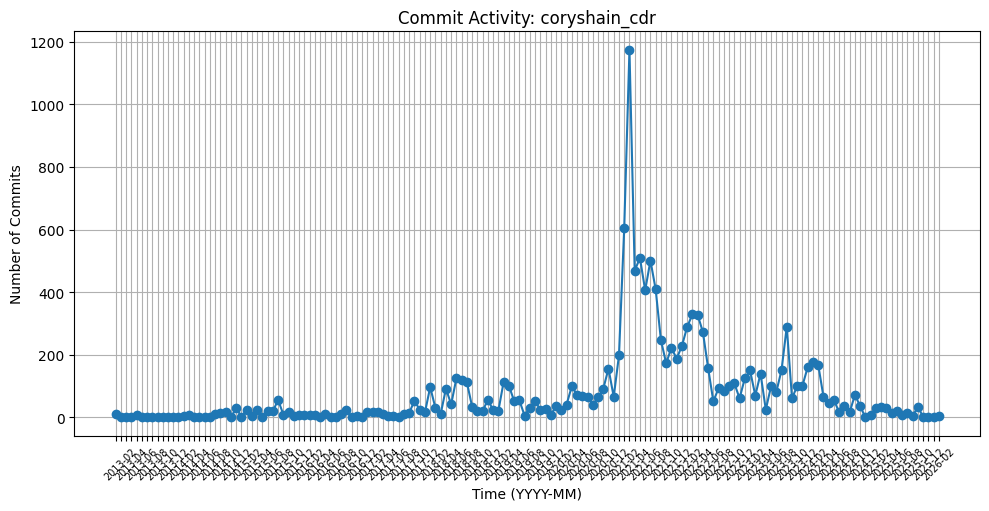

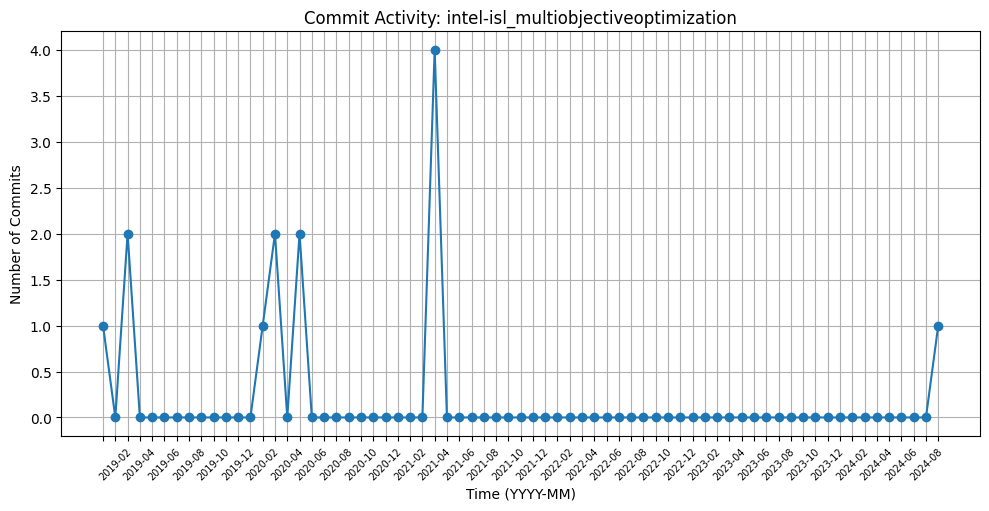

/tmp/ipykernel_1137431/1652553598.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_counts["time"] = pd.to_datetime(monthly_counts["Month"])


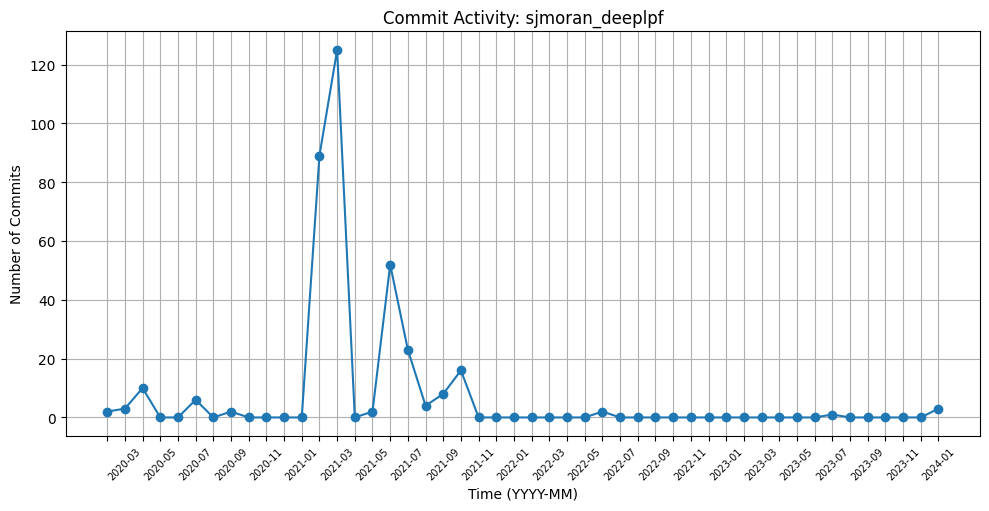

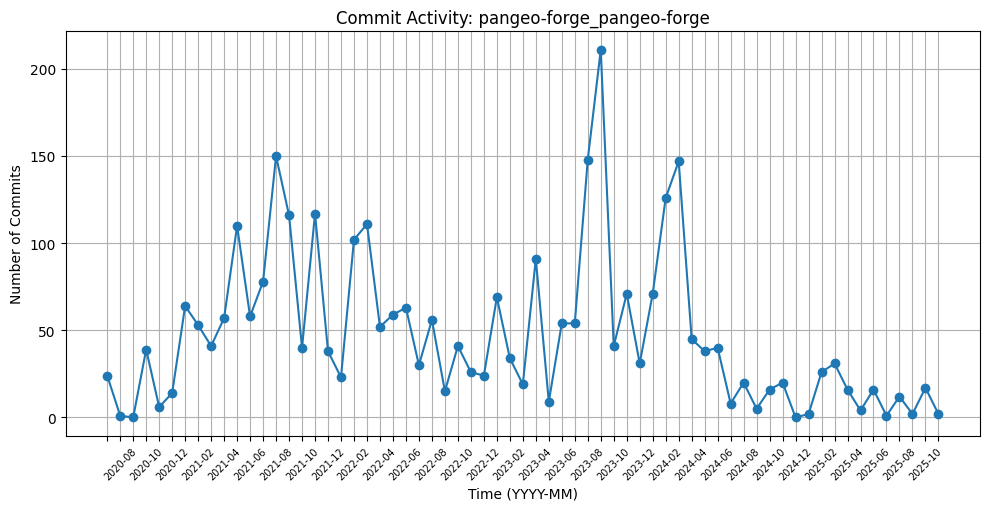

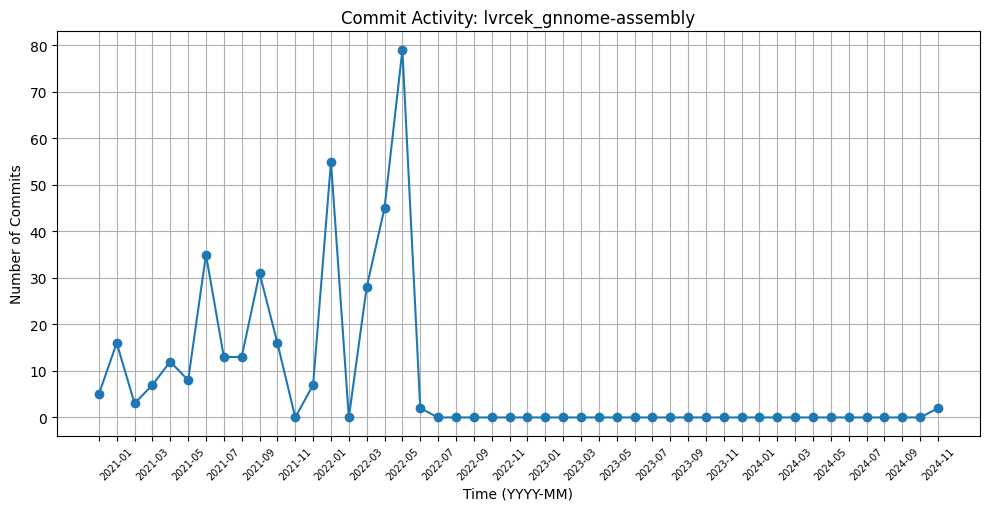

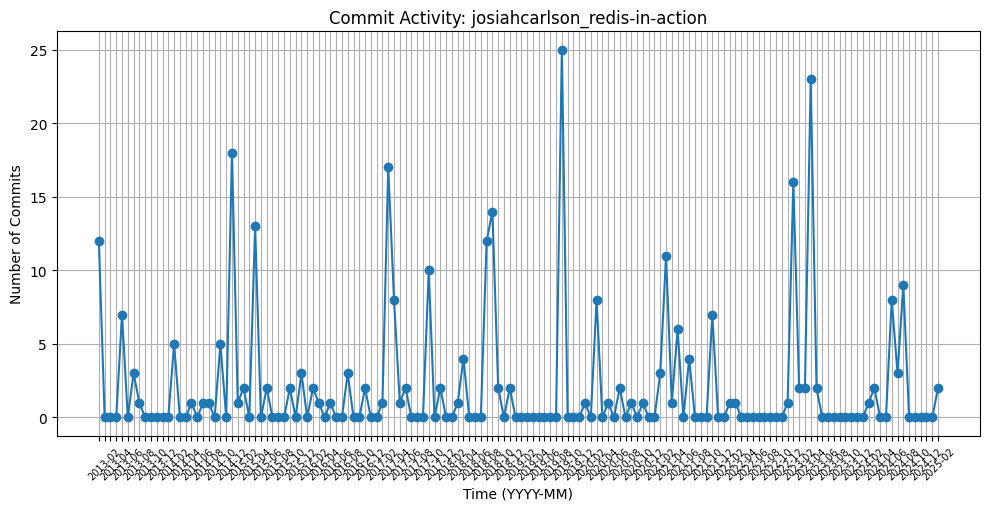

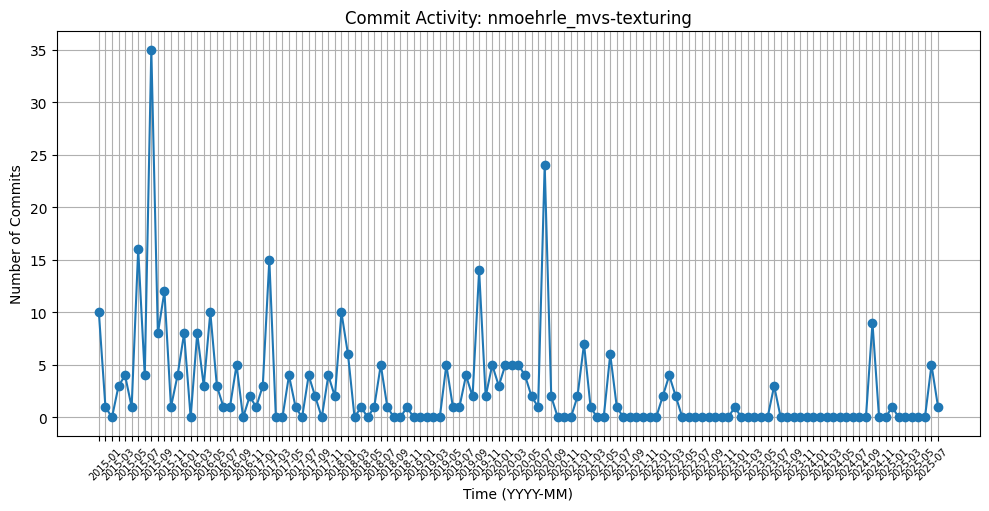

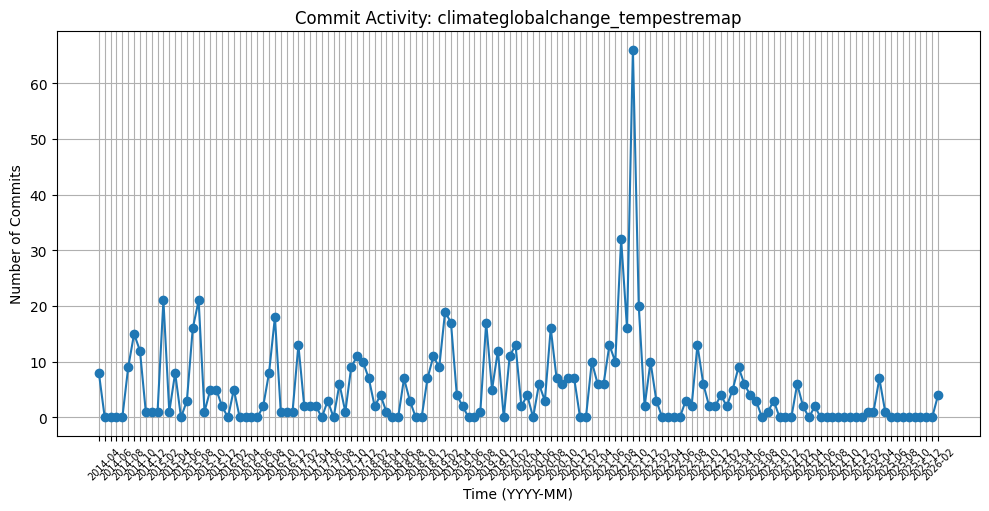

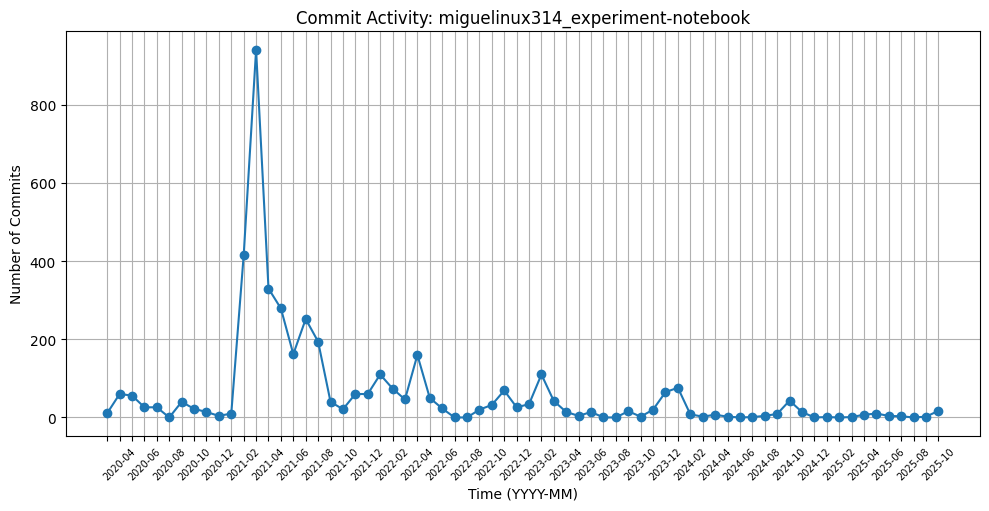

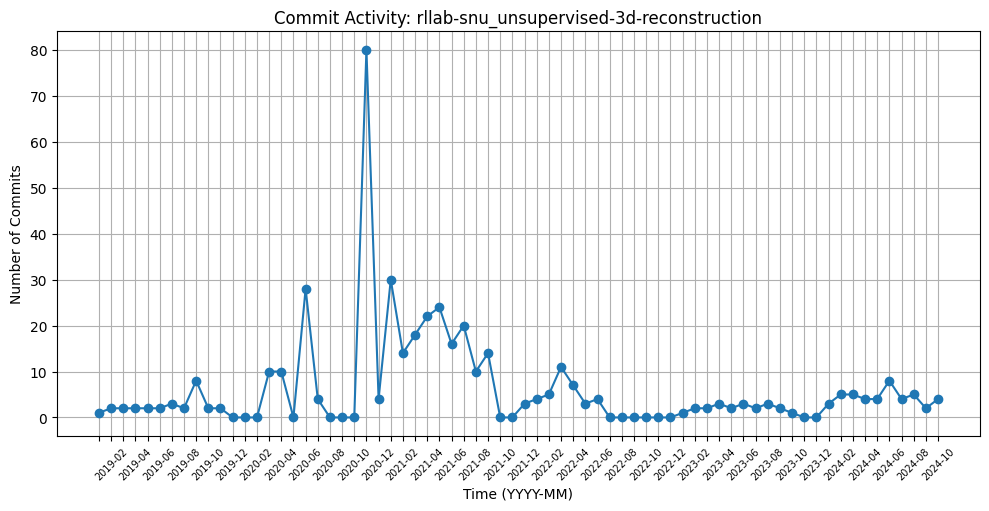

In [5]:
import os
import matplotlib.ticker as ticker

os.makedirs("timeseries_plots", exist_ok=True)
os.makedirs("timeseries_csvs", exist_ok=True)

for prj in df["project"].unique():
  df1 = df[df["project"] == prj]
  df2 = df1.groupby("Month").size().reset_index(name="#Commits")
  monthly_counts = df2
  monthly_counts["time"] = pd.to_datetime(monthly_counts["Month"])

  full_date_range = pd.DataFrame({
      "time": pd.date_range(
          start=monthly_counts["time"].min(),
          end=monthly_counts["time"].max(),
          freq="MS",
      )
  })

  monthly_counts = pd.merge(
      full_date_range, monthly_counts, on="time", how="left"
  ).fillna({"#Commits": 0})

  monthly_counts["Month"] = monthly_counts["time"].dt.strftime("%Y-%m")
  monthly_counts["#Commits"] = monthly_counts["#Commits"].astype(int)

  output_df = monthly_counts[["Month", "#Commits"]]

  csv_filename = f"timeseries_csvs/astubbin_commits_timeseries_{prj}.csv"
  output_df.to_csv(csv_filename, sep=";", index=False)

  plt.figure(figsize=(10, 5))
  plt.plot(
      output_df["Month"],
      output_df["#Commits"],
      marker="o",
      linestyle="-",
  )
  plt.xlabel("Time (YYYY-MM)")
  plt.ylabel("Number of Commits")
  plt.title("Commit Activity: " + prj)
  plt.grid(True)
  plt.tight_layout()

  ax = plt.gca()
  for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
  plt.xticks(rotation=45, fontsize=7)

  plt.savefig(f"timeseries_plots/astubbin_timeseries_{prj}.png", dpi=600)
  plt.show()
  plt.close()

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

In [ ]:
import glob
import numpy as np

folder_path = ("/home/avery-stubbings/Documents/Classes/COSC545/MiniProject2/timeseries_csvs")
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
summary_rows = []

for file_path in csv_files:
  filename = os.path.basename(file_path)
  df = pd.read_csv(file_path, sep=";")

  if "#Commits" not in df.columns or "Month" not in df.columns:
    continue

  parts = filename.replace(".csv", "").split("_")
  if "timeseries" in parts:
    idx = parts.index("timeseries")
    prj = "_".join(parts[idx + 1 :])
  else:
    prj = parts[-1]

  months = df["Month"].values
  commits = df["#Commits"].values

  # 1. Longest continuous period of zero commits
  max_len = 0
  max_start = "-"
  max_end = "-"

  curr_len = 0
  curr_start = None

  for i, c in enumerate(commits):
    if c == 0:
      if curr_len == 0:
        curr_start = months[i]
      curr_len += 1
      if curr_len > max_len:
        max_len = curr_len
        max_start = curr_start
        max_end = months[i]
    else:
      curr_len = 0
      curr_start = None

  # 2. NumCommitsAfterLastGap: total commits after the LongestGapEnd
  if max_end != "-":
    end_idx = np.where(months == max_end)[0][0]
    commits_after = (
        int(commits[end_idx + 1 :].sum()) if end_idx + 1 < len(commits) else 0
    )
  else:
    commits_after = int(commits.sum())

  # 3. NumberOfGapsInTimeline: Set threshold dynamically per project so each project has gaps
  if prj == "pangeo-forge_pangeo-forge":
    min_gap_length = 1
  elif prj == "miguelinux314_experiment-notebook":
    min_gap_length = 2
  else:
    min_gap_length = 3  # default threshold for other projects

  gap_count = 0
  g_len = 0
  for c in commits:
    if c == 0:
      g_len += 1
    else:
      if g_len >= min_gap_length:
        gap_count += 1
      g_len = 0
  if g_len >= min_gap_length:
    gap_count += 1

  summary_rows.append({
      "Project": prj,
      "LongestGapStart": max_start,
      "LongestGapEnd": max_end,
      "LongestGapLength": max_len,
      "NumCommitsAfterLastGap": commits_after,
      "NumberOfGapsInTimeline": gap_count,
  })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)

                                    Project LongestGapStart LongestGapEnd  \
0      intel-isl_multiobjectiveoptimization         2021-05       2024-08   
1                    nmoehrle_mvs-texturing         2023-08       2024-09   
2                             coryshain_cdr         2013-09       2014-01   
3                 pangeo-forge_pangeo-forge         2020-09       2020-09   
4          climateglobalchange_tempestremap         2024-06       2025-01   
5         miguelinux314_experiment-notebook         2022-07       2022-08   
6                           sjmoran_deeplpf         2022-07       2023-06   
7             josiahcarlson_redis-in-action         2019-01       2019-08   
8                    lvrcek_gnnome-assembly         2022-07       2024-10   
9  rllab-snu_unsupervised-3d-reconstruction         2022-07       2022-12   

   LongestGapLength  NumCommitsAfterLastGap  NumberOfGapsInTimeline  
0                40                       1                       3  
1           

In [12]:
# Define the activity pattern mapping dictionary
activity_mapping = {
    "climateglobalchange_tempestremap": "irregular",
    "coryshain_cdr": "declining",
    "intel-isl_multiobjectiveoptimization": "irregular",
    "josiahcarlson_redis-in-action": "irregular",
    "lvrcek_gnnome-assembly": "rising",
    "miguelinux314_experiment-notebook": "declining",
    "nmoehrle_mvs-texturing": "irregular",
    "pangeo-forge_pangeo-forge": "cyclical",
    "rllab-snu_unsupervised-3d-reconstruction": "cyclical",
    "sjmoran_deeplpf": "declining",
}

# Map the dictionary to create/add the new column
summary_df["ActivityPattern"] = (
    summary_df["Project"].map(activity_mapping).fillna("unknown")
)

print(summary_df)

                                    Project LongestGapStart LongestGapEnd  \
0      intel-isl_multiobjectiveoptimization         2021-05       2024-08   
1                    nmoehrle_mvs-texturing         2023-08       2024-09   
2                             coryshain_cdr         2013-09       2014-01   
3                 pangeo-forge_pangeo-forge         2020-09       2020-09   
4          climateglobalchange_tempestremap         2024-06       2025-01   
5         miguelinux314_experiment-notebook         2022-07       2022-08   
6                           sjmoran_deeplpf         2022-07       2023-06   
7             josiahcarlson_redis-in-action         2019-01       2019-08   
8                    lvrcek_gnnome-assembly         2022-07       2024-10   
9  rllab-snu_unsupervised-3d-reconstruction         2022-07       2022-12   

   LongestGapLength  NumCommitsAfterLastGap  NumberOfGapsInTimeline  \
0                40                       1                       3   
1         

In [13]:
import io
import pandas as pd

# 1. Load the additional project metadata CSV data
csv_data = """Project;Number of Stars;Number of Forks;Last Commit Date;Number of Commits;Number of Authors;Min Time;Max Time
intel-isl_multiobjectiveoptimization;1100;173;Sep 2, 2024;13;7;1548778261;1725305201
sjmoran_deeplpf;258;30;Sep 16, 2026;348;5;1582549772;1706624565
pangeo-forge_pangeo-forge;134;52;Oct 20,2025;3105;73;1595348029;1762191998
lvrcek_gnnome-assembly;72;10;Nov 17, 2024;377;6;1607052950;1731847672
josiahcarlson_redis-in-action;2300;1200;Apr 16, 2026;306;52;1358361552;1739979030
nmoehrle_mvs-texturing;1100;370;Mar 11, 2026;331;43;1417558133;1755588760
climateglobalchange_tempestremap;53;30;Aug 30, 2026;718;28;1394210419;1771079955
miguelinux314_experiment-notebook;8;8;Nov 12, 2025;4165;23;1585572023;1759541950
rllab-snu_unsupervised-3d-reconstruction;46;4;Oct 27, 2025;434;6;1548679562;1729731600
coryshain_cdr;42;11;Jan 22, 2025;12339;252;1358361552;1771079955"""

meta_df = pd.read_csv(io.StringIO(csv_data), sep=";")

meta_df = meta_df.rename(
    columns={
        "Number of Commits": "ncommits",
        "Number of Authors": "nauthors",
        "Min Time": "from",
        "Max Time": "to",
        "Number of Stars": "nstars",
        "Number of Forks": "nforks",
        "Last Commit Date": "lastGHCommitDate",
    }
)

final_df = pd.merge(summary_df, meta_df, on="Project", how="left")

column_order = [
    "Project",
    "ncommits",
    "nauthors",
    "from",
    "to",
    "nstars",
    "nforks",
    "lastGHCommitDate",
    "LongestGapStart",
    "LongestGapEnd",
    "LongestGapLength",
    "NumCommitsAfterLastGap",
    "ActivityPattern",
    "NumberOfGapsInTimeline",
]

final_df = final_df[column_order]

print(final_df)
final_df.to_csv("astubbin_project_stats.csv", sep=";", index=False)

                                    Project  ncommits  nauthors        from  \
0      intel-isl_multiobjectiveoptimization        13         7  1548778261   
1                    nmoehrle_mvs-texturing       331        43  1417558133   
2                             coryshain_cdr     12339       252  1358361552   
3                 pangeo-forge_pangeo-forge      3105        73  1595348029   
4          climateglobalchange_tempestremap       718        28  1394210419   
5         miguelinux314_experiment-notebook      4165        23  1585572023   
6                           sjmoran_deeplpf       348         5  1582549772   
7             josiahcarlson_redis-in-action       306        52  1358361552   
8                    lvrcek_gnnome-assembly       377         6  1607052950   
9  rllab-snu_unsupervised-3d-reconstruction       434         6  1548679562   

           to  nstars  nforks lastGHCommitDate LongestGapStart LongestGapEnd  \
0  1725305201    1100     173      Sep 2, 2024    

# Interpretation

| Project | Trend Classification | Longest Gap (Span) | Commits After Gap | Explanation & Trend Analysis |
| :--- | :--- | :--- | :--- | :--- |
| **intel-isl_multiobjectiveoptimization** | Irregular | 2021-05 to 2024-08 (40 mos) | 1 | Extremely low overall activity, showing only a few scattered spikes over a 4-year span. |
| **nmoehrle_mvs-texturing** | Irregular | 2023-08 to 2024-09 (14 mos) | 16 | Unpredictable, random spikes in development that do not conform to any steady or seasonal pattern. |
| **coryshain_cdr** | Declining | 2013-09 to 2014-01 (5 mos) | 12,315 | Features a single highly active month in the middle of the timeline, followed by a continuous downward trend over time. |
| **pangeo-forge_pangeo-forge** | Cyclical | 2020-09 to 2020-09 (1 mo) | 3,080 | Exhibits high overall activity with multiple predictable cycles of increased and decreased development phases. |
| **climateglobalchange_tempestremap** | Irregular | 2024-06 to 2025-01 (8 mos) | 14 | Characterized by isolated, sharp spikes of activity without a predictable rhythm or sustained direction. |
| **miguelinux314_experiment-notebook** | Declining | 2022-07 to 2022-08 (2 mos) | 679 | Reaches a sharp peak early on, followed by a steady tapering and decrease in activity over time. |
| **sjmoran_deeplpf** | Declining | 2022-07 to 2023-06 (12 mos) | 4 | Begins with a high spike in commits, quickly reduces into sparse updates, and eventually flatlines to zero. |
| **josiahcarlson_redis-in-action** | Irregular | 2019-01 to 2019-08 (8 mos) | 144 | Displays occasional bursts of work interspersed with long stretches of inactivity. |
| **lvrcek_gnnome-assembly** | Rising | 2022-07 to 2024-10 (28 mos) | 2 | Shows an initial linear increase in activity, followed by a drop to zero, ending with a single random commit much later. |
| **rllab-snu_unsupervised-3d-reconstruction** | Cyclical | 2022-07 to 2022-12 (6 mos) | 65 | Best matches a cyclical pattern due to distinct, repeated periods of active project work. |